# Data mining \& clustering

The goal if this practical is to adress the folowing problem:
<center style="color:red" >  Given XXX raw, unlabeled documents, ... How to exploit/understand/represent them?</center>

In the previous week, we have seen how to represent textual data with the Bag of Words (BoW) model:
$$X =
	\begin{matrix}
	 & \textbf{t}_j \\
	 & \downarrow \\
	\textbf{d}_i \rightarrow &
	\begin{pmatrix}
	x_{1,1} & \dots & x_{1,d} \\
	\vdots & \ddots & \vdots \\
	x_{N,1} & \dots & x_{N,d} \\
	\end{pmatrix}
	\end{matrix}
	$$

From this BoW representation, we want to answer the following questions:
1. Which clustering algorithm to choose?
    - K-means, LSA, pLSA, LDA
1. What results to expect?
    - Semantics, noise cleaning, etc...
1. Which qualitative and quantitative analyses to understand the groups?
[comment]: <> (%1. Comment boucler, itérer pour améliorer la qualité du processus?)


<span style="color:magenta" > In this practical, we use a **labeled dataset** in order to evaluate performances with quantitative and well-defined metrics. </span>


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import codecs
import re
import os.path
import sklearn

## Data loading



In [2]:
from sklearn.datasets import fetch_20newsgroups
newsgroups_train = fetch_20newsgroups(subset='train')

In [3]:
# conversion BoW + tf-idf
from sklearn.feature_extraction.text import TfidfVectorizer
#vectorizer = TfidfVectorizer()
# ici on fixe la longueur de vocaburary -> 1000
vectorizer = TfidfVectorizer(max_df=0.95, min_df=2, max_features=1000, stop_words='english')

vectors = vectorizer.fit_transform(newsgroups_train.data)
print(vectors.shape)

# sparsity measure = 44 active words over 1000 per document (157 over 130000) !!
print(vectors.nnz / float(vectors.shape[0]))

(11314, 1000)
44.164928407283014


In [4]:
# retrieve words
print([(i,vectorizer.get_feature_names_out()[i]) \
       for i in np.random.randint(vectors.shape[1], size=10)])

[(np.int64(583), 'manual'), (np.int64(917), 'turkey'), (np.int64(332), 'dos'), (np.int64(836), 'son'), (np.int64(739), 'radio'), (np.int64(748), 'reasonable'), (np.int64(755), 'related'), (np.int64(567), 'lot'), (np.int64(124), 'armenians'), (np.int64(931), 'university')]


In [5]:
# labels (only for evaluation)
Y = newsgroups_train.target
print(Y[:10])
print([newsgroups_train.target_names[i] for i in Y[:20]]) # vraie classe

[ 7  4  4  1 14 16 13  3  2  4]
['rec.autos', 'comp.sys.mac.hardware', 'comp.sys.mac.hardware', 'comp.graphics', 'sci.space', 'talk.politics.guns', 'sci.med', 'comp.sys.ibm.pc.hardware', 'comp.os.ms-windows.misc', 'comp.sys.mac.hardware', 'rec.motorcycles', 'talk.religion.misc', 'comp.sys.mac.hardware', 'sci.space', 'misc.forsale', 'alt.atheism', 'comp.graphics', 'rec.autos', 'sci.electronics', 'comp.windows.x']


# 0) Word clouds
### Drawing word clouds from the raw corpus or words' frequencies :  [make word clouds !](https://github.com/amueller/word_cloud)

### Installation
If you are using pip:

`pip install wordcloud`

### If you are using conda, you can install from the conda-forge channel:

`conda install -c conda-forge wordcloud`

### Let's look at the most frequent words in this dataset

In [6]:
data = np.array(newsgroups_train.data)
corpus = "".join(data)
words = corpus.split() # optional args to choose the splitting chars
print("Nb mots=",len(words))

Nb mots= 3252437


### Plot the N frequent words and verify that its follows a Zipf law

[('the', 127670), ('to', 69836), ('of', 66705), ('a', 56148), ('and', 52580), ('is', 39554), ('in', 37787), ('I', 37616), ('that', 34582), ('>', 27843), ('for', 25707), ('you', 19874), ('it', 19698), ('be', 18364), ('on', 18201), ('have', 17292), ('are', 17260), ('with', 16179), ('not', 15434), ('The', 14079)]


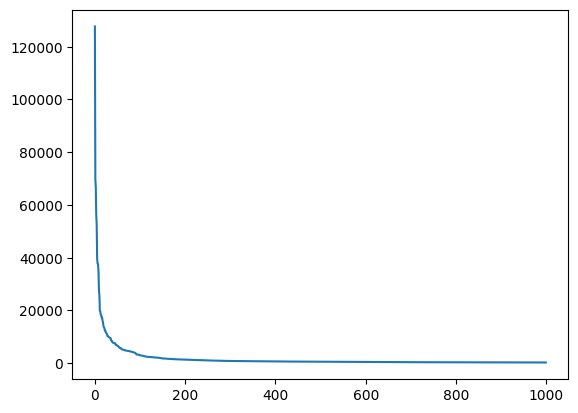

In [7]:
from collections import Counter

wc = Counter()
wc.update(words)
freq = [f for w,f in wc.most_common(1000)]
plt.plot(freq[:1000])
print(wc.most_common(20))

### Experiment word clouds

(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

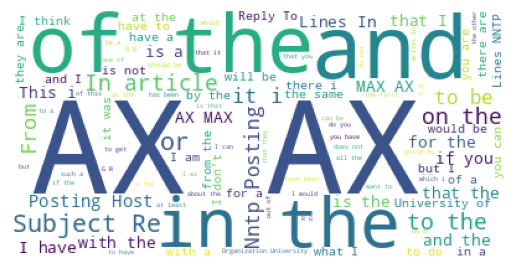

In [8]:
from wordcloud import WordCloud
wordcloud = WordCloud(background_color='white', stopwords = [], max_words=100).generate(corpus)

plt.figure()
plt.imshow(wordcloud)
plt.axis('off')

(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

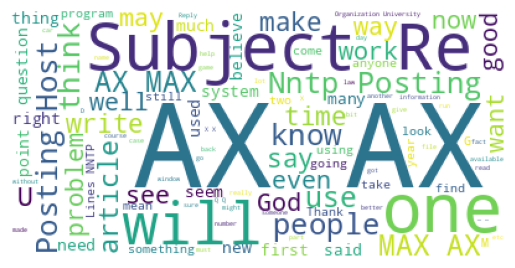

In [9]:
from wordcloud import STOPWORDS # Note: this is the default option
wordcloud = WordCloud(background_color='white', stopwords = STOPWORDS, max_words=100).generate(corpus)

plt.figure()
plt.imshow(wordcloud)
plt.axis("off")

### Use word clouds with generate\_from\_frequencies.
N.B.: retrieve the most words frequencies using a CountVectorizer

(np.float64(-0.5), np.float64(799.5), np.float64(399.5), np.float64(-0.5))

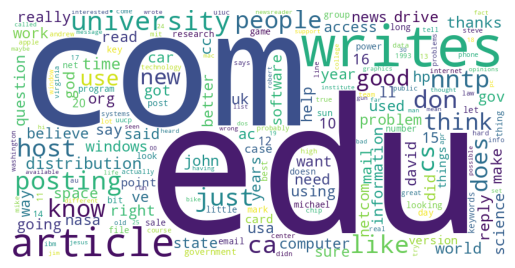

In [10]:
# Mutiplier le centroid avec les vecteurs
from sklearn.feature_extraction.text import CountVectorizer

#vectorizer = CountVectorizer(lowercase=True, strip_accents='unicode')
#X = vectorizer.fit_transform(newsgroups_train)
vocab = vectorizer.get_feature_names_out()
freq = np.asarray(vectors.sum(axis=0)).flatten()
word_freq = dict(zip(vocab, freq))
wordcloud = WordCloud(width=800, height=400, background_color="white")
wordcloud.generate_from_frequencies(word_freq)

plt.figure()
plt.imshow(wordcloud)
plt.axis("off")

### Drawing word clouds from classes


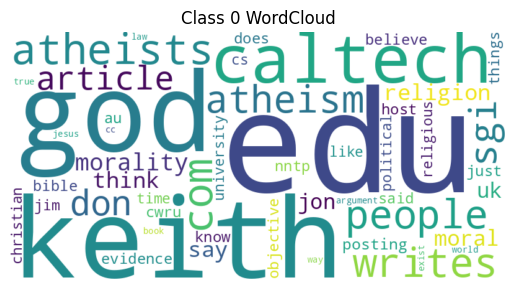

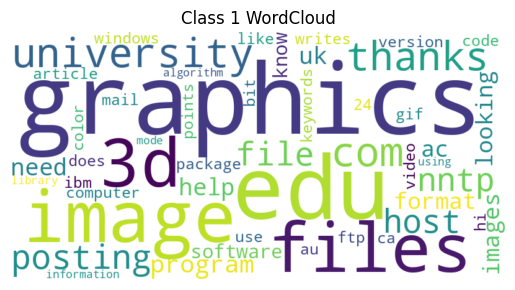

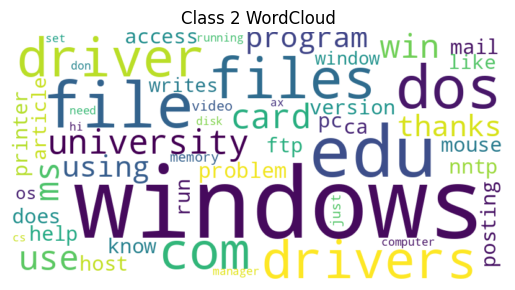

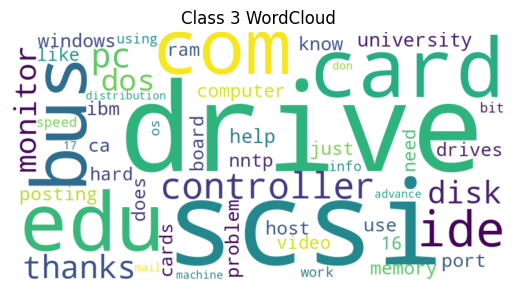

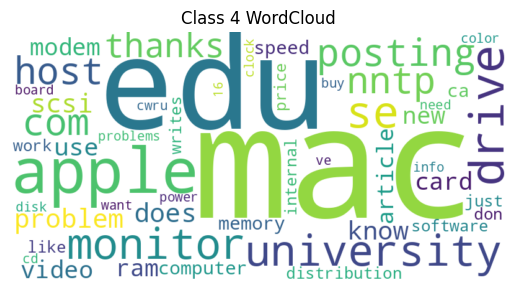

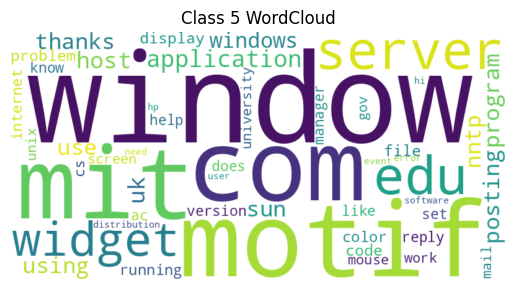

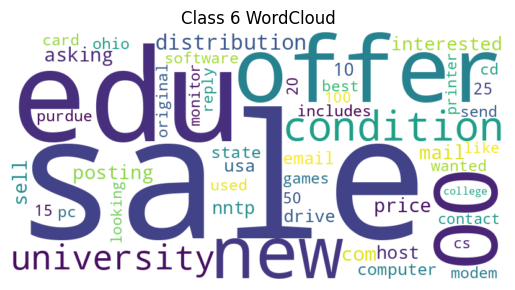

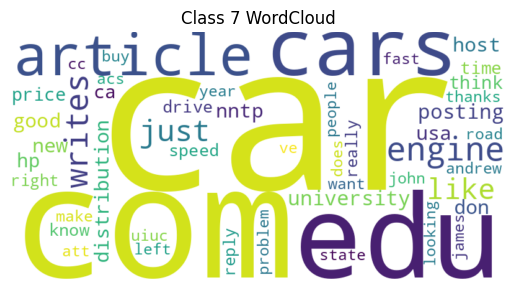

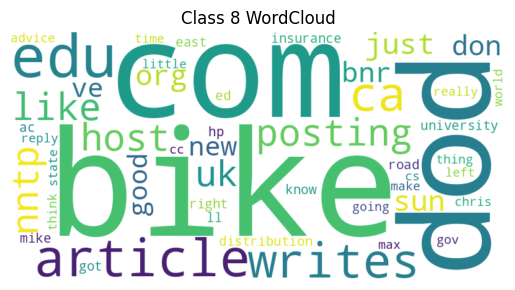

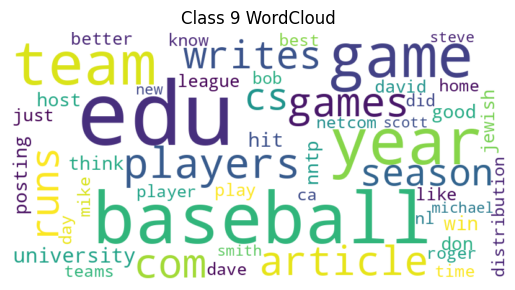

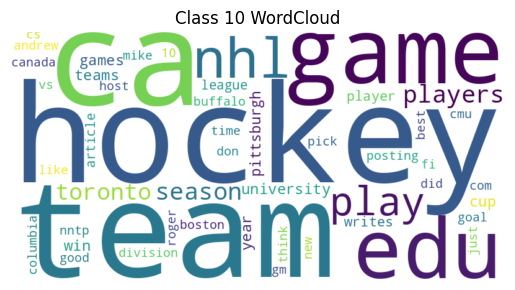

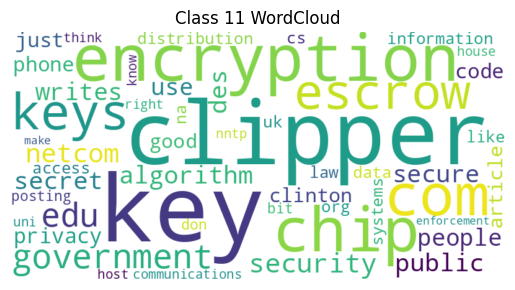

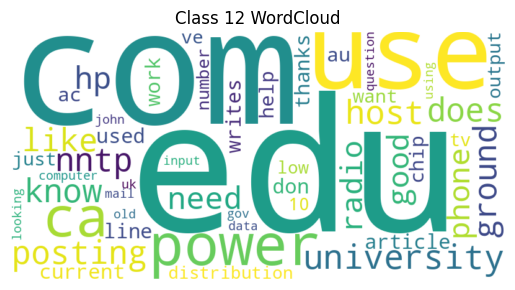

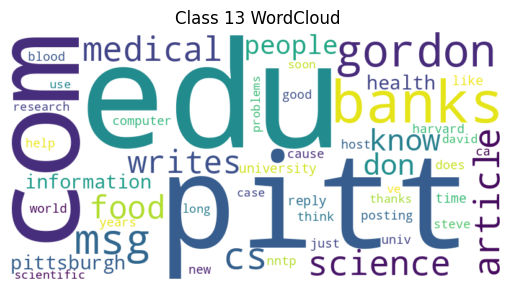

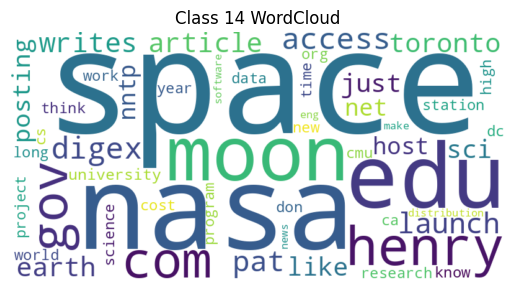

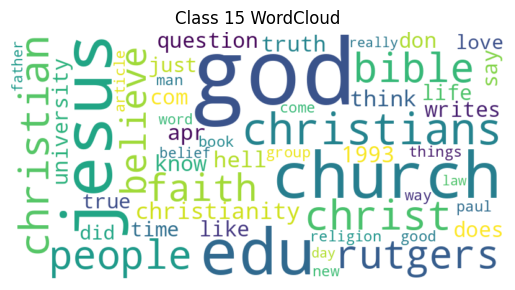

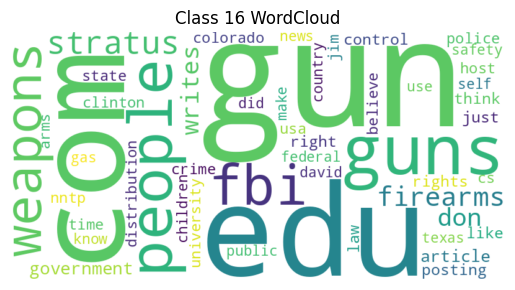

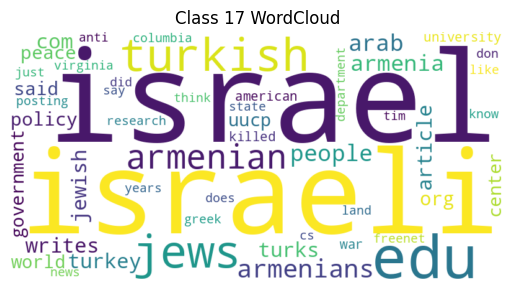

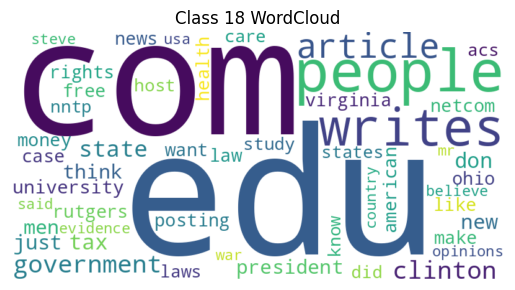

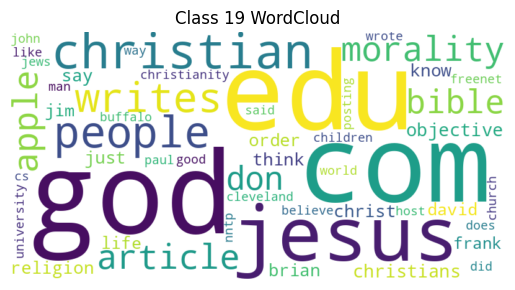

In [11]:
n_classes = len(np.unique(newsgroups_train.target))

for c in range(n_classes):
    # select documents in this class
    class_docs = vectors[newsgroups_train.target == c]
    
    # compute centroid (mean vector)
    centroid = class_docs.mean(axis=0).A1  # .A1 to convert sparse → 1D array
    
    # make a dict {word: frequency}
    freqs = {vocab[i]: centroid[i] for i in range(len(vocab))}
    
    # generate WordCloud
    wc = WordCloud(width=800, height=400, background_color="white", max_words=50)
    wc.generate_from_frequencies(freqs)
    
    # plot
    plt.figure()
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"Class {c} WordCloud")
    plt.show()


# 1) Clustering algorithm: K-Means

**Let's start by the most famous and simple unsupervised algorithm: $k$-means!**
Look at [sklear documentation](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)
and apply it to your BoW matrix.


In [12]:
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize

svd = TruncatedSVD(n_components=20) # number of latent dimensions to keep
X_lsa = svd.fit_transform(vectors)   # shape: (n_docs, n_components)
X_lsa = normalize(X_lsa, norm='l2', axis=1)

In [13]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=20, n_init=10) # 10 random starts
clusters = kmeans.fit_predict(X_lsa)

### Clustering Analysis:
1. **Qualtitative:**
    - Look at the most important words for each cluster
    - Perform cluster assignement to each document, and compute word cloud on the document (raw text or frequencies)

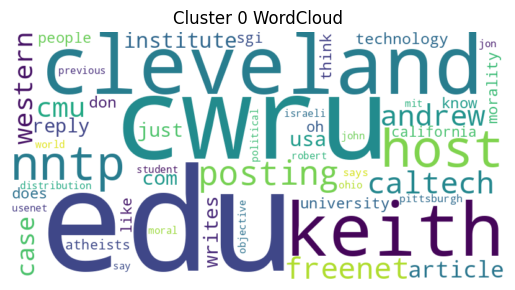

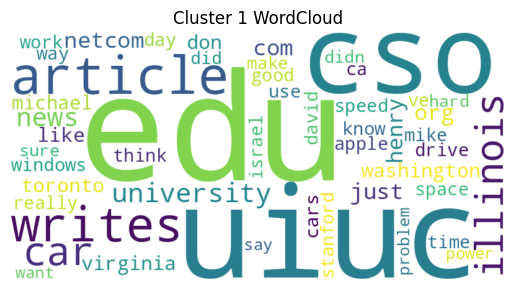

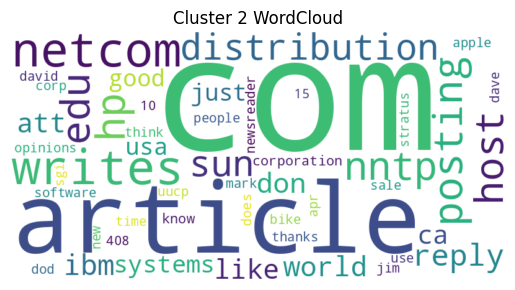

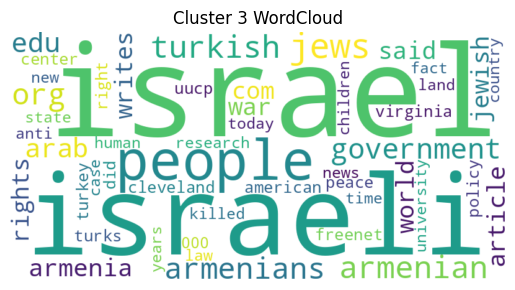

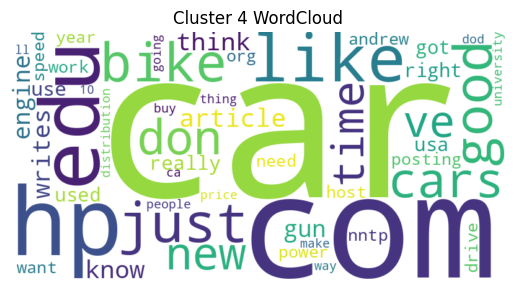

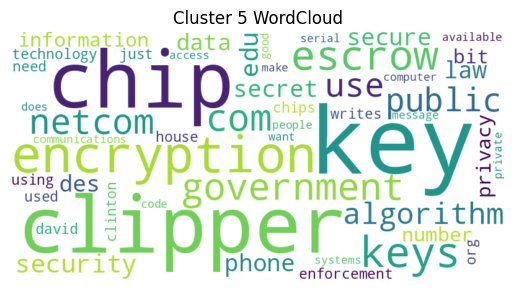

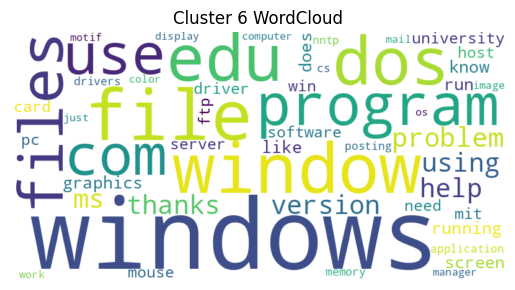

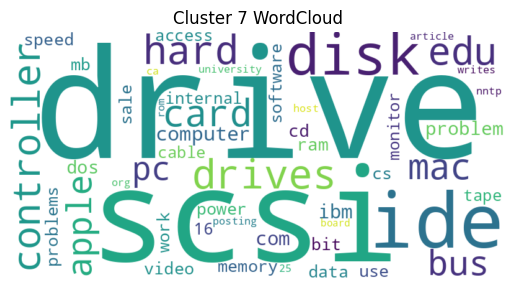

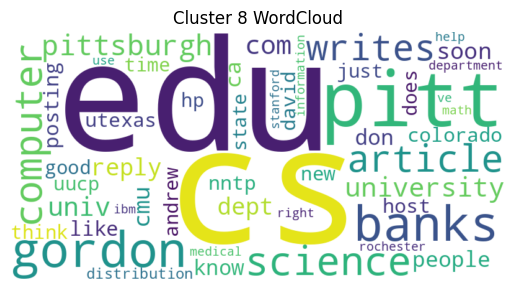

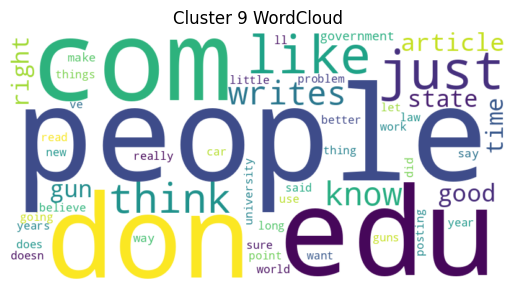

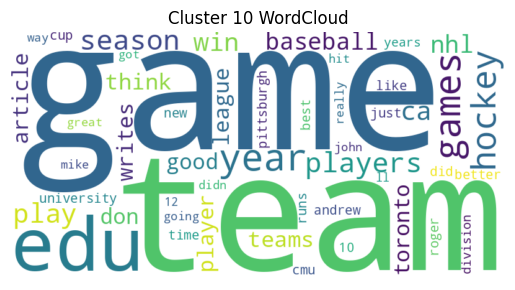

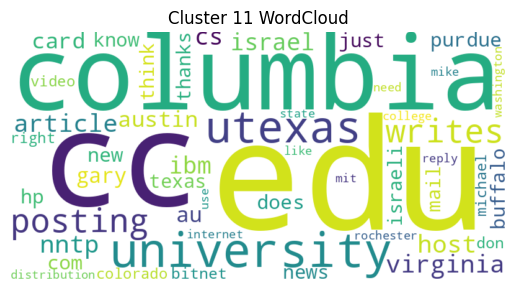

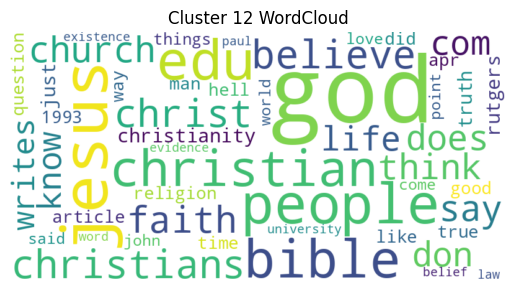

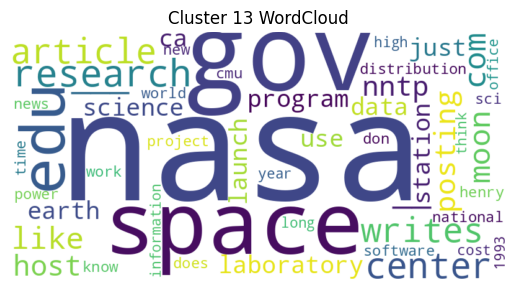

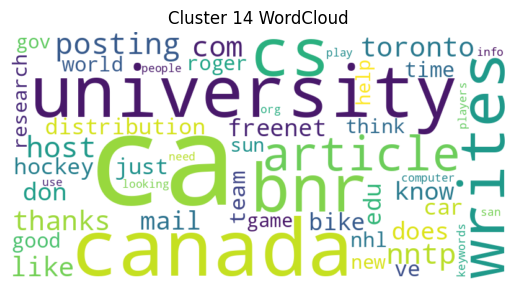

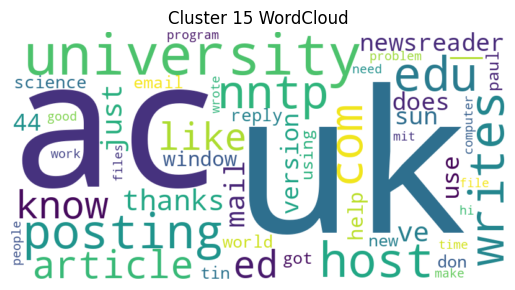

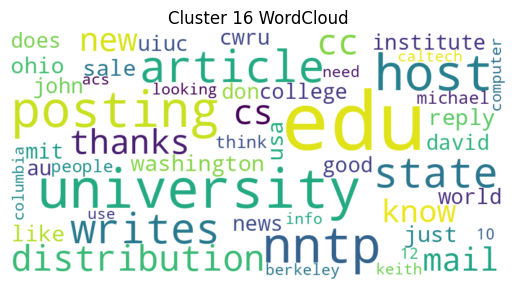

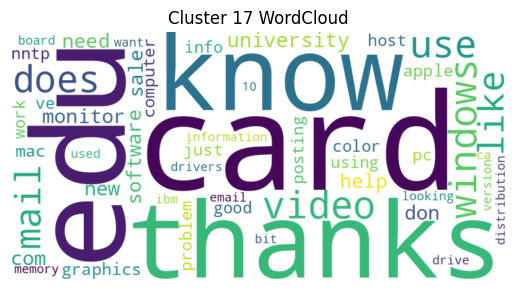

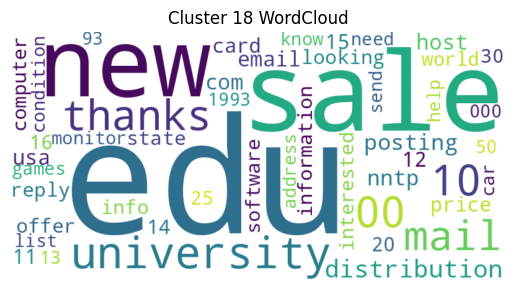

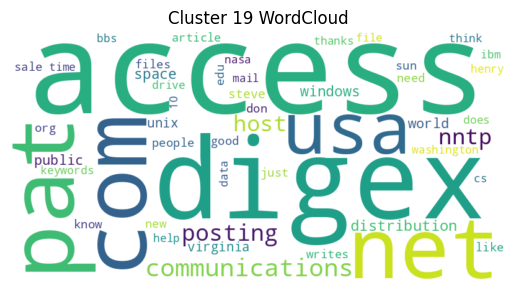

In [14]:

for k in range(20):
    centroid = kmeans.cluster_centers_[k]             # shape (n_components,)
    word_scores = centroid @ svd.components_         # shape (n_words,)
    freqs = dict(zip(vocab, word_scores))

    wc = WordCloud(
        width=800,
        height=400,
        background_color="white",
        max_words=50,
        min_font_size=8,
        relative_scaling=0.5
    )
    wc.generate_from_frequencies(freqs)

    plt.figure()
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Cluster {k} WordCloud")
    plt.show()

2. **Quantitative:**
    - Compute cluster "purity": $p_j= |y^*_j|$, where $y^*_j$ is the most frequent (GT) label in cluster $C_j$ $\Rightarrow$ $p = \frac{1}{N}\sum\limits_j  p_j$
    - Compute [Rand Score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.rand_score.html) and [Adjusted Rand Score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.adjusted_rand_score.html#sklearn.metrics.adjusted_rand_score)


In [23]:
def purity_score(y_true, y_pred):
    purity_sum = 0
    for c in np.unique(y_pred):
        labels = y_true[y_pred == c]
        _, count = Counter(labels).most_common(1)[0]
        purity_sum += count

    purity = purity_sum / N
    return purity

In [ ]:
y_true = newsgroups_train.target
y_pred = clusters
N = len(y_true)
purity = purity_score(y_true, y_pred)
print("Cluster purity:", purity)

Cluster purity: 0.3518649460844971


Rand Index(RI) compares pairs of documents:
- Are they in the same cluster?
- Are they in the same true class?

In [16]:
from sklearn.metrics import rand_score

ri = rand_score(y_true, y_pred)
print("Rand Index:", ri)

Rand Index: 0.9096421850924161


Adjusted Rand Index (ARI)
- Corrects for chance
- Random clustering -> score ≈ 0
- Perfect clustering -> 1
- Can be negative (worse than random)

In [17]:
from sklearn.metrics import adjusted_rand_score

ari = adjusted_rand_score(y_true, y_pred)
print("Adjusted Rand Index:", ari)

Adjusted Rand Index: 0.16353774548962546


t-SNE is a visualization algorithm that takes high-dimensional data (like TF-IDF or LSA vectors) and maps it to 2D or 3D, trying to keep similar points close together.

In [18]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, init='pca', max_iter=5000, random_state=0)
tsne_mat = tsne.fit_transform(X_lsa)

# 2) Latent Semantic Analysis (LSA <=> SVD)


**Remember the LSA factorziation**:
$$
\begin{matrix}
 & X  &\!\!\!\!\!=\!\!\!\!\!& U  & \Sigma & V^T \\
  & \textbf{t}_j   &  & \hat{ \textbf{d}_i} & &  \\
 & \downarrow  &  &\downarrow  & & \\
\textbf{d}_i \rightarrow
&
\begin{pmatrix}
x_{1,1} & \dots & x_{1,d} \\
\\
\vdots & \ddots & \vdots \\
\\
x_{N,1} & \dots & x_{N,d} \\
\end{pmatrix}
&
\!\!\!\!\!=\!\!\!\!\!
%&
%(\hat{ \textbf{t}_j}) \rightarrow
&
\begin{pmatrix}
\begin{pmatrix} &  \textbf{u}_1 &  \end{pmatrix} \\
\vdots \\
\begin{pmatrix}  & \textbf{u}_k &  \end{pmatrix}
\end{pmatrix}
%&
%\!\!\!\!\!\cdot\!\!\!\!\!
&
\begin{pmatrix}
\sigma_1 & \dots & 0 \\
\vdots & \ddots & \vdots \\
0 & \dots & \sigma_k \\
\end{pmatrix}
%&
%\!\!\!\!\!\cdot\!\!\!\!\!
&
\begin{pmatrix}
\begin{pmatrix} \, \\ \, \\ \textbf{v}_1 \\ \, \\ \,\end{pmatrix}
\dots
\begin{pmatrix} \, \\ \, \\ \textbf{v}_k \\ \, \\ \, \end{pmatrix}
\end{pmatrix}
\end{matrix}
$$

- Look at [SVD doc in skelarn](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html#sklearn.decomposition.TruncatedSVD)
- Do the same qualitative/quantitative evaluation than with K-Means
- You can also use LSA as a pre-processing step for K-Means, *i.e.* running K-Means on $\boldsymbol{U}$ matrix above
    - N.B. : try without/with $\ell_2$ normalization of $\boldsymbol{U}$'s rows before running  K-Means
    - You can also benefit from LSA pre-processing for using [t-SNE visualization](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html) (see code below)


/var/folders/my/27r6mb7d4sg2pyvcl7qgcf680000gn/T/ipykernel_1199/317605265.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('hsv', 20)
/var/folders/my/27r6mb7d4sg2pyvcl7qgcf680000gn/T/ipykernel_1199/317605265.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('jet', 20)


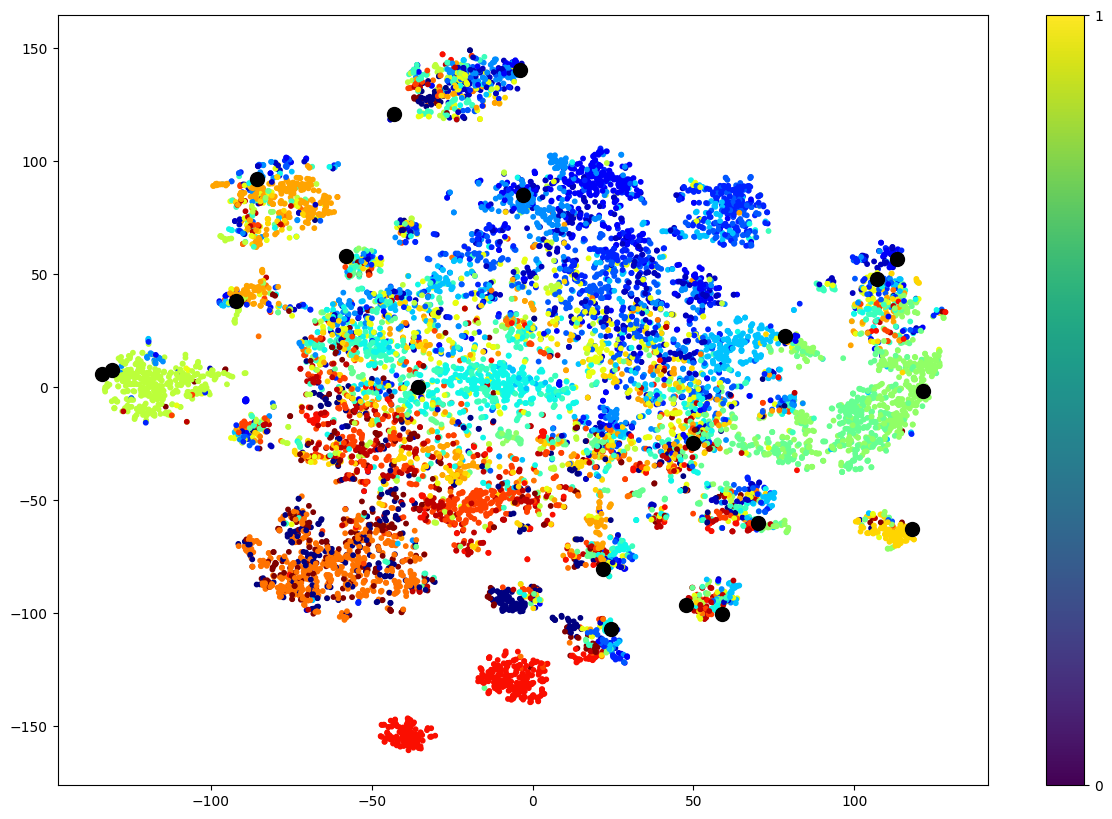

In [19]:
from sklearn.preprocessing import normalize

NN2cluster = np.argmax(np.abs(X_lsa), axis=0)
#import seaborn as sns
import matplotlib.cm as cm
cmap = cm.tab20
cmap = cm.get_cmap('hsv', 20)
cmap = cm.get_cmap('jet', 20)
#cmap = cm.tab20

plt.figure(figsize=(15,10))
plt.scatter(tsne_mat[:,0],tsne_mat[:,1], c=Y, cmap=cmap, s=10)
plt.scatter(tsne_mat[NN2cluster[:],0],tsne_mat[NN2cluster[:],1], c='black', s=100)
#plt.scatter(tsne_mat[NN2cluster2[:],0],tsne_mat[NN2cluster2[:],1], c='red', s=100)
plt.colorbar(ticks=range(20))

# 3) Latent Dirichlet Allocation (LDA)

Perform the same experiments with LDA:
- LDA
https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.LatentDirichletAllocation.html


**Start with a CountVectorizer**

In [20]:
from nltk.tokenize import RegexpTokenizer
from sklearn.feature_extraction.text import CountVectorizer

# Initialize regex tokenizer
tokenizer = RegexpTokenizer(r'\w+')

# Vectorize document using TF-IDF
vectorizer = CountVectorizer(lowercase=True,
                        stop_words='english',
                        ngram_range = (1,1),
                        tokenizer = tokenizer.tokenize, max_df=0.95, min_df=2, max_features=1000)

vectors = vectorizer.fit_transform(newsgroups_train.data)
print(vectors.shape)
print(vectors.nnz / float(vectors.shape[0]))



/Users/sitaraliang/Downloads/sorbonne/M1/S2/RITAL/tme/venv/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


(11314, 1000)
48.02527841612162


## LDA-viz

In [21]:
from sklearn.decomposition import LatentDirichletAllocation

n_topics = 20
lda = LatentDirichletAllocation(
    n_components=n_topics,
    max_iter=10,
    learning_method='online'
)

lda.fit(vectors)

,"n_components n_components: int, default=10Number of topics... versionchanged:: 0.19 ``n_topics`` was renamed to ``n_components``",20
,"doc_topic_prior doc_topic_prior: float, default=NonePrior of document topic distribution `theta`. If the value is None,defaults to `1 / n_components`.In [1]_, this is called `alpha`.",None
,"topic_word_prior topic_word_prior: float, default=NonePrior of topic word distribution `beta`. If the value is None, defaultsto `1 / n_components`.In [1]_, this is called `eta`.",None
,"learning_method learning_method: {'batch', 'online'}, default='batch'Method used to update `_component`. Only used in :meth:`fit` method.In general, if the data size is large, the online update will be muchfaster than the batch update.Valid options:- 'batch': Batch variational Bayes method. Use all training data in each EM update. Old `components_` will be overwritten in each iteration.- 'online': Online variational Bayes method. In each EM update, use mini-batch of training data to update the ``components_`` variable incrementally. The learning rate is controlled by the ``learning_decay`` and the ``learning_offset`` parameters... versionchanged:: 0.20 The default learning method is now ``""batch""``.",'online'
,"learning_decay learning_decay: float, default=0.7It is a parameter that control learning rate in the online learningmethod. The value should be set between (0.5, 1.0] to guaranteeasymptotic convergence. When the value is 0.0 and batch_size is``n_samples``, the update method is same as batch learning. In theliterature, this is called kappa.",0.7
,"learning_offset learning_offset: float, default=10.0A (positive) parameter that downweights early iterations in onlinelearning. It should be greater than 1.0. In the literature, this iscalled tau_0.",10.0
,"max_iter max_iter: int, default=10The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the :meth:`fit` method, and not the:meth:`partial_fit` method.",10
,"batch_size batch_size: int, default=128Number of documents to use in each EM iteration. Only used in onlinelearning.",128
,"evaluate_every evaluate_every: int, default=-1How often to evaluate perplexity. Only used in `fit` method.set it to 0 or negative number to not evaluate perplexity intraining at all. Evaluating perplexity can help you check convergencein training process, but it will also increase total training time.Evaluating perplexity in every iteration might increase training timeup to two-fold.",-1
,"total_samples total_samples: int, default=1e6Total number of documents. Only used in the :meth:`partial_fit` method.",1000000.0
,"perp_tol perp_tol: float, default=1e-1Perplexity tolerance. Only used when ``evaluate_every`` is greater than 0.",0.1


In [22]:
# pip install install pyldavis
from __future__ import print_function

import pyLDAvis
import pyLDAvis.lda_model
pyLDAvis.enable_notebook()


pyLDAvis.lda_model.prepare(lda,vectors,vectorizer)

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
18    -0.196344  0.122750       1        1  13.191679
8      0.334499  0.161465       2        1   8.501411
11    -0.116451 -0.040959       3        1   8.215776
3      0.317158  0.112432       4        1   7.314377
0     -0.084165 -0.106640       5        1   7.249521
19    -0.175958  0.084191       6        1   6.411080
4      0.235479 -0.117892       7        1   5.411791
9     -0.078823 -0.174830       8        1   4.756758
5     -0.106880 -0.002807       9        1   4.746259
6     -0.135101  0.061075      10        1   4.616864
16    -0.163426  0.133473      11        1   4.480012
2     -0.189326  0.146219      12        1   4.081783
10     0.008004 -0.176373      13        1   3.829192
15     0.328946 -0.073742      14        1   3.823394
14    -0.073326  0.020778      15        1   3.588599
7     -0.001460 -0.226581      16        1   3.025934
1     -0.016025 -0.144970      17        1   2.312253
13    -0.128129  0.119461      18        1   1.851395
17    -0.015026 -0.075107      19        1   1.392938
12     0.256354  0.178057      20        1   1.198983, topic_info=    Term          Freq         Total Category  logprob  loglift
146   ax  63189.000000  63189.000000  Default  30.0000  30.0000
0      0   9413.000000   9413.000000  Default  29.0000  29.0000
243  com  12073.000000  12073.000000  Default  28.0000  28.0000
9      1  15041.000000  15041.000000  Default  27.0000  27.0000
992    x   8932.000000   8932.000000  Default  26.0000  26.0000
..   ...           ...           ...      ...      ...      ...
871    t     57.529606  18769.272979  Topic20  -5.4186  -1.3640
9      1     50.474161  15041.266762  Topic20  -5.5495  -1.2734
27     2     38.453701  10103.442867  Topic20  -5.8215  -1.1475
288    d     25.779031   5644.613381  Topic20  -6.2214  -0.9652
147    b     18.182614   3310.379021  Topic20  -6.5705  -0.7807

[910 rows x 6 columns], token_table=      Topic      Freq  Term
term                       
0         2  0.003824     0
0         4  0.002231     0
0        14  0.993849     0
1         4  0.001974    00
1         7  0.417217    00
...     ...       ...   ...
997      15  0.546557  york
999       2  0.066697     z
999       4  0.899819     z
999      14  0.032757     z
999      20  0.000395     z

[3630 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[19, 9, 12, 4, 1, 20, 5, 10, 6, 7, 17, 3, 11, 16, 15, 8, 2, 14, 18, 13])

# Performances evaluation

**Compare the different approaches wrt three quantitative metrics.**

Three quantitative metrics:
- Purity
- Rand Index (RI)
- Adjusted Rand Index (ARI)

In [29]:
vectorizer = TfidfVectorizer(max_df=0.95, min_df=2, max_features=1000, stop_words='english')
vectors = vectorizer.fit_transform(newsgroups_train.data)

In [30]:
# LSA + KMeans
X_lsa = normalize(TruncatedSVD(n_components=20).fit_transform(vectors))
clusters = KMeans(n_clusters=20, n_init=10).fit_predict(X_lsa)
y_true = newsgroups_train.target
y_pred = clusters
purity = purity_score(y_true, y_pred)
ri = rand_score(y_true, y_pred)  
ari = adjusted_rand_score(y_true, y_pred)  
print("Cluster purity:", purity, " Rand Index: ", ri, "Adjusted Rand Index: ", ari)

Cluster purity: 0.34479406045607214  Rand Index:  0.9068682390965005 Adjusted Rand Index:  0.15366444716806235


In [ ]:
# LDA
doc_topics = lda.fit_transform(vectors)
y_pred_lda = np.argmax(doc_topics, axis=1) 
purity_lda = purity_score(y_true, y_pred_lda)
ri_lda = rand_score(y_true, y_pred_lda)
ari_lda = adjusted_rand_score(y_true, y_pred_lda)
print("Cluster purity:", purity_lda, " Rand Index: ", ri_lda, "Adjusted Rand Index: ", ari_lda)

Cluster purity: 0.18578751988686584  Rand Index:  0.7021091918059917 Adjusted Rand Index:  0.0990940427064524
